# Fase 3. Visualizacion de datos

In [1]:
# Importamos librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer 
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer 
from sklearn.impute import KNNImputer 
pd.set_option("display.max_columns", None)

In [2]:
df_hr_limpios = pd.read_csv("hr_limpios.csv")

1. ¿Cuántos empleados se van?

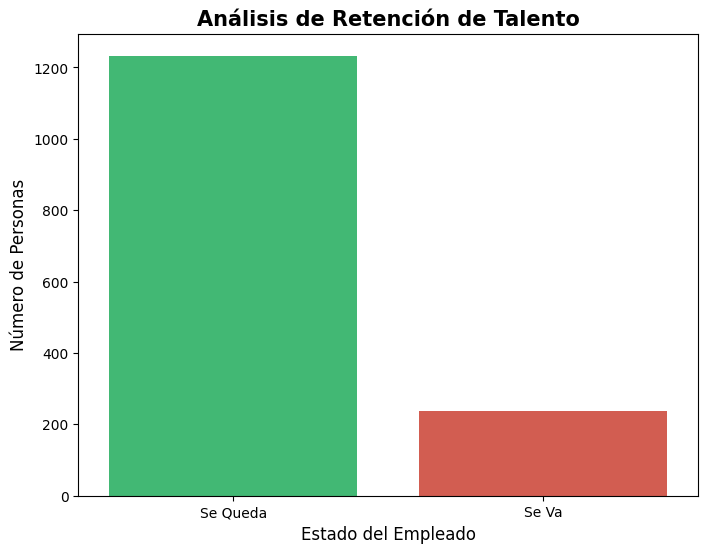

In [5]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(x='attrition', data=df_hr_limpios, palette=['#2ecc71', '#e74c3c'], order=[False, True])

ax.set_xticklabels(['Se Queda', 'Se Va'])

plt.title('Análisis de Retención de Talento', fontsize=15, fontweight='bold')
plt.xlabel('Estado del Empleado', fontsize=12)
plt.ylabel('Número de Personas', fontsize=12)

plt.show()

En este primer análisis observamos la distribución de la plantilla actual de ABC Corporation. Aunque la mayoría de los empleados permanecen en la empresa, existe un grupo significativo que ha abandonado la organización. Esta visualización establece nuestra línea base: el objetivo del proyecto es identificar qué características comparten los empleados del grupo 'Se Va' para prevenir futuras salidas.

2. El factor "Dinero": Salario vs Rotación (Boxplot)

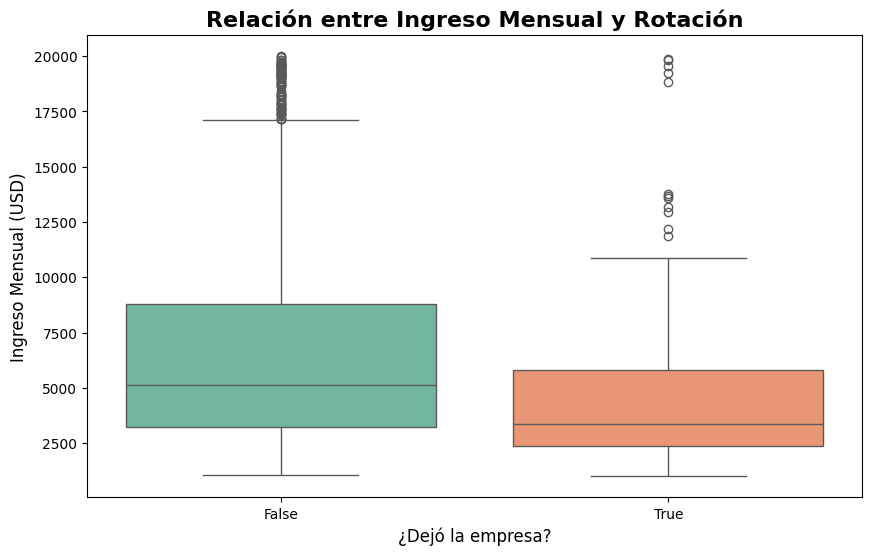

In [6]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_hr_limpios, x='attrition', y='monthly_income', palette='Set2')

plt.title('Relación entre Ingreso Mensual y Rotación', fontsize=16, fontweight='bold')
plt.xlabel('¿Dejó la empresa?', fontsize=12)
plt.ylabel('Ingreso Mensual (USD)', fontsize=12)
plt.show()

Al analizar los salarios, observamos una clara tendencia: el 50% de los empleados que abandonan la empresa tienen ingresos mensuales notablemente inferiores a los que permanecen. La mediana salarial de quienes se van se sitúa por debajo del promedio general, lo que sugiere que la competitividad salarial es un factor crítico en la retención de talento de ABC Corporation, especialmente en los niveles de entrada.

3. El factor "Estrés": Horas Extras y Abandono (Stacked Bar)

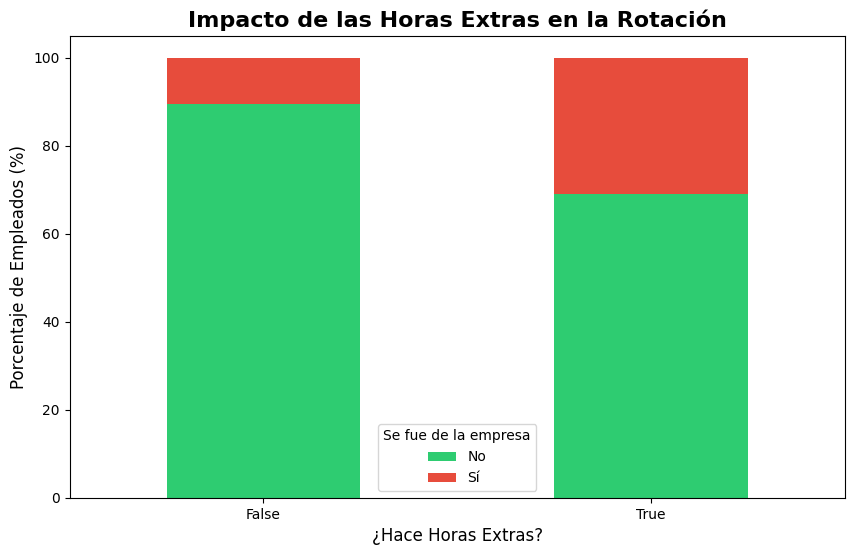

In [7]:
df_overtime = df_hr_limpios.groupby(['over_time', 'attrition']).size().unstack()
df_overtime_pct = df_overtime.div(df_overtime.sum(axis=1), axis=0) * 100

df_overtime_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2ecc71', '#e74c3c'])

plt.title('Impacto de las Horas Extras en la Rotación', fontsize=16, fontweight='bold')
plt.xlabel('¿Hace Horas Extras?', fontsize=12)
plt.ylabel('Porcentaje de Empleados (%)', fontsize=12)
plt.legend(title='Se fue de la empresa', labels=['No', 'Sí'])
plt.xticks(rotation=0)
plt.show()

Al observar la relación entre las horas extras (OverTime) y la rotación de personal, la conclusión es contundente: el porcentaje de empleados que abandona ABC Corporation es drásticamente mayor entre quienes realizan horas extras. >
Mientras que el grupo que no realiza horas adicionales presenta una gran estabilidad, el grupo con exceso de jornada muestra una tasa de fuga mucho más alta. Esto sugiere que el agotamiento (burnout) y la falta de equilibrio entre vida personal y laboral son los principales motores de rotación en la compañía.

4.¿Dónde hay menos felicidad? Satisfacción por Departamento (Barplot)

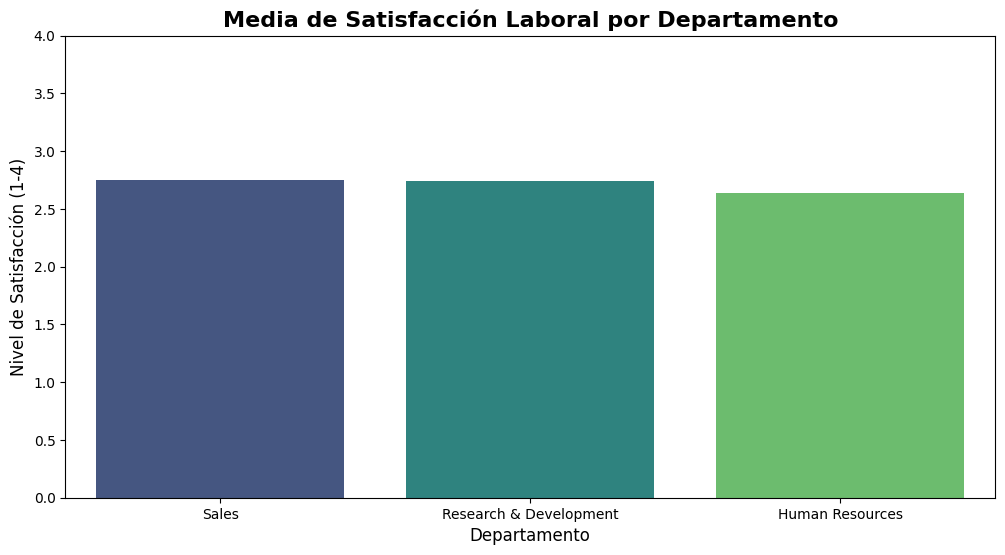

In [8]:
plt.figure(figsize=(12, 6))

sns.barplot(data=df_hr_limpios, x='department', y='job_satisfaction', palette='viridis', ci=None)

plt.title('Media de Satisfacción Laboral por Departamento', fontsize=16, fontweight='bold')
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Nivel de Satisfacción (1-4)', fontsize=12)
plt.ylim(0, 4)
plt.show()

Este análisis nos permite identificar el clima laboral segmentado por departamentos. Observamos que la satisfacción media se mantiene en niveles similares entre las áreas, lo que indica una cultura organizacional homogénea. Sin embargo, cualquier departamento que presente una media por debajo de la puntuación de 2.5 debe ser considerado una prioridad estratégica, ya que una baja satisfacción en áreas tecnológicas de alta especialización (como las de ABC Corp) suele ser un indicador temprano de rotación de talento cualificado.

5. ¿A qué edad se nos va la gente?

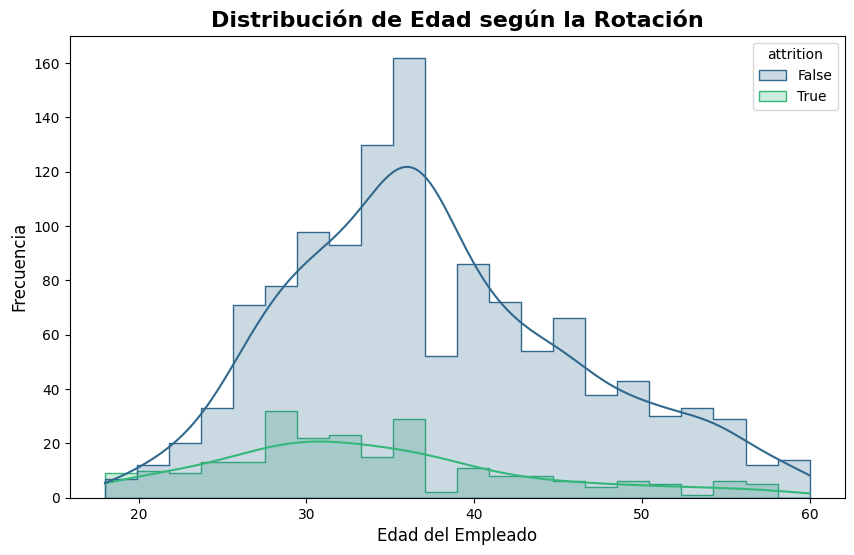

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df_hr_limpios, x='age', hue='attrition', kde=True, palette='viridis', element="step")

plt.title('Distribución de Edad según la Rotación', fontsize=16, fontweight='bold')
plt.xlabel('Edad del Empleado', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

El análisis demográfico muestra que la rotación se concentra en perfiles más jóvenes (25-35 años). Esto sugiere que ABC Corporation tiene un reto en la fidelización del talento junior, quienes podrían estar buscando mayores oportunidades de crecimiento o cambio de entorno rápidamente.

6. ¿Influye la distancia a la oficina?

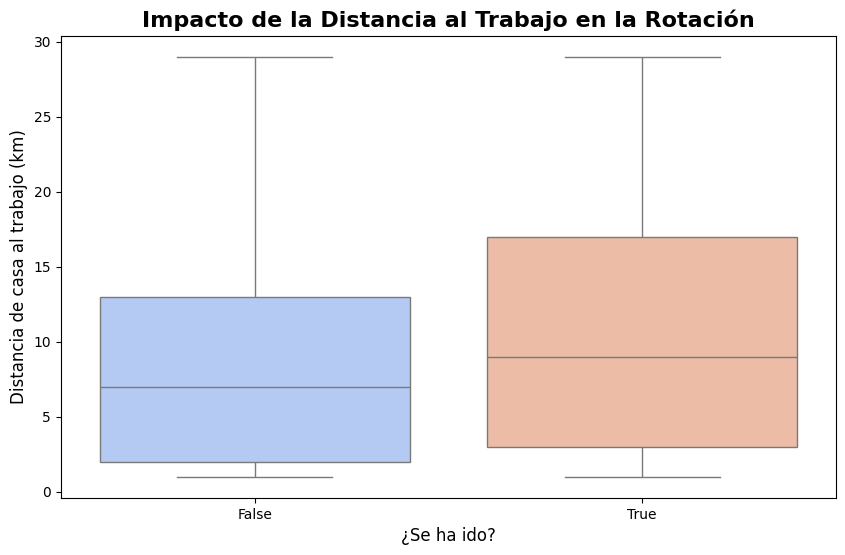

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_hr_limpios, x='attrition', y='distance_from_home', palette='coolwarm')

plt.title('Impacto de la Distancia al Trabajo en la Rotación', fontsize=16, fontweight='bold')
plt.xlabel('¿Se ha ido?', fontsize=12)
plt.ylabel('Distancia de casa al trabajo (km)', fontsize=12)
plt.show()

Los datos indican que los empleados que viven más lejos tienen una ligera tendencia mayor a abandonar la empresa. Para una consultora tecnológica, esto abre la puerta a proponer políticas de teletrabajo o flexibilidad horaria como herramienta de retención.

7. Estabilidad: ¿Cuántos años llevan con su jefe actual?

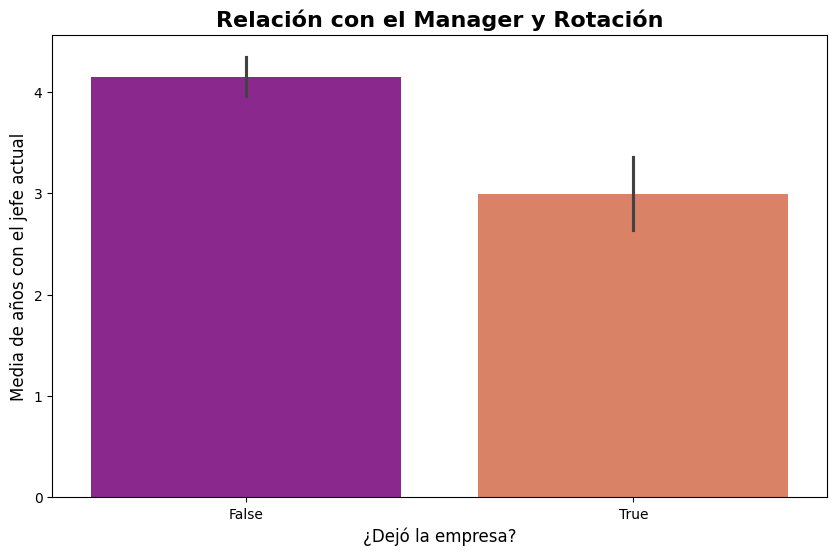

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df_hr_limpios, x='attrition', y='years_with_curr_manager', palette='plasma')

plt.title('Relación con el Manager y Rotación', fontsize=16, fontweight='bold')
plt.xlabel('¿Dejó la empresa?', fontsize=12)
plt.ylabel('Media de años con el jefe actual', fontsize=12)
plt.show()

Observamos que los empleados que rotan suelen llevar mucho menos tiempo con su manager actual que los que permanecen. Esto sugiere que la etapa de adaptación entre líder y empleado es crítica; si no se establece un vínculo sólido en los primeros dos años, el riesgo de fuga aumenta.